# Pregunta 4
## ¿Las regiones con mayor desarrollo económico presentan un mejor desempeño educativo?

## Avance del proyecto .


### 1. Contexto de los dataset.

se utilizarán dos fuentes de información del año 2023. La primera corresponde a los resultados SIMCE de 2° medio, desde los cuales se construirá un promedio regional en lectura y matemática. La segunda corresponde al PIB regional, que se usará como una aproximación del nivel de desarrollo económico de cada región.

A partir de estas bases, se podrá comparar si existe una asociación entre el nivel de actividad económica regional y los resultados educativos promedio. Este análisis permite explorar desigualdades territoriales y observar si el desarrollo económico de una región se refleja también en el ámbito educacional.

### 2. Imports.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# estilo general de gráficos
sns.set(style="whitegrid")

# tamaño por defecto
plt.rcParams["figure.figsize"] = (8, 5)


### 3. Cargar Datasets.

In [50]:

simce_region = pd.read_csv("simce2m2023_region_público_final.csv", sep=";", encoding="latin1")

# cargar archivo PIB regional
pib = pd.read_excel("CCNN2018_PIB_REGIONAL_T.xlsx", sheet_name="Cuadro", header=2)

### 3.1 Revisión Inicial.

In [51]:
# ver tamaño de ambas bases
print("SIMCE región:", simce_region.shape)

# ver columnas
print(simce_region.columns.tolist())

# primeras filas
simce_region.head()

SIMCE región: (16, 12)
['cod_reg', 'nom_reg', 'prom_lect2m_reg', 'prom_mate2m_reg', 'dif_lect2m_reg', 'dif_mate2m_reg', 'sigdif_lect2m_reg', 'sigdif_mate2m_reg', 'fecha_bbdd', 'codigo_bbdd', 'grado', 'agno']


,cod_reg,nom_reg,prom_lect2m_reg,prom_mate2m_reg,dif_lect2m_reg,dif_mate2m_reg,sigdif_lect2m_reg,sigdif_mate2m_reg,fecha_bbdd,codigo_bbdd,grado,agno
0,1,Región de Tarapacá,243,250,5,6,0,0,20240418,final20240418v1,2m,2023
1,2,Región de Antofagasta,244,249,2,3,0,0,20240418,final20240418v1,2m,2023
2,3,Región de Atacama,245,250,4,6,0,0,20240418,final20240418v1,2m,2023
3,4,Región de Coquimbo,247,253,4,5,0,0,20240418,final20240418v1,2m,2023
4,5,Región de Valparaíso,244,251,2,3,0,0,20240418,final20240418v1,2m,2023


In [52]:
# ver tamaño de ambas bases
print("PIB:", pib.shape)

# ver columnas
print(pib.columns.tolist())

# primeras filas
pib.head()

PIB: (12, 16)
['Periodo', '1. Región de Arica y Parinacota', '2. Región de Tarapacá', '3. Región de Antofagasta', '4. Región de Atacama', '5. Región de Coquimbo', '6. Región de Valparaíso', '7. Región Metropolitana de Santiago', '8. Región del Libertador General Bernardo OHiggins', '9. Región del Maule', '10. Región de Ñuble', '11. Región del Biobío', '12. Región de La Araucanía', '13. Región de Los Ríos', '14. Región de Los Lagos', '15. Región de Aysén del General Carlos Ibáñez del Campo']


,Periodo,1. Región de Arica y Parinacota,2. Región de Tarapacá,3. Región de Antofagasta,4. Región de Atacama,5. Región de Coquimbo,6. Región de Valparaíso,7. Región Metropolitana de Santiago,8. Región del Libertador General Bernardo OHiggins,9. Región del Maule,10. Región de Ñuble,11. Región del Biobío,12. Región de La Araucanía,13. Región de Los Ríos,14. Región de Los Lagos,15. Región de Aysén del General Carlos Ibáñez del Campo
0,2013-01-01,1282.495083,3973.900772,15350.246976,3623.905262,5577.723873,13629.012944,70299.909193,6883.877966,6017.991359,2339.615555,9770.039084,4398.990980,2107.480298,5009.700620,1102.787237
1,2014-01-01,1307.001181,4030.284211,16081.807900,3748.813434,5362.921044,13299.766766,71508.318652,7041.796645,6014.109978,2369.973499,10141.863773,4469.095734,2188.772484,5355.865879,1142.839449
2,2015-01-01,1339.014735,4027.257850,16094.025137,3656.726271,5369.852359,13302.883948,73320.465929,7444.469815,6497.895689,2486.890671,10389.010765,4673.277885,2271.262934,5428.098181,1086.116693
3,2016-01-01,1354.814236,3919.976944,15358.844342,3805.463289,5435.124054,13707.635862,74877.243336,7602.785728,6631.525873,2625.904097,10561.615419,4943.526764,2343.665911,5606.774696,1088.222488
4,2017-01-01,1409.354761,4076.794360,14900.585126,3769.645421,5551.983807,13928.348616,75707.568957,7500.973374,6643.890647,2593.703344,10801.253086,5042.397292,2382.377808,6033.201832,1199.669829


### 3.3 Selección de variables.

In [53]:
# quedarnos con las columnas importantes de SIMCE
base_simce = simce_region[[
    "cod_reg",
    "nom_reg",
    "prom_lect2m_reg",
    "prom_mate2m_reg",
    "grado",
    "agno"
]].copy()

### 3.4 Promedio SIMCE.

In [54]:
# crear una medida resumen del desempeño educativo regional
base_simce["prom_simce"] = (
    base_simce["prom_lect2m_reg"] + base_simce["prom_mate2m_reg"]
) / 2

In [14]:
# ver primeras filas de la base lista
base_simce.head()

,cod_reg,nom_reg,prom_lect2m_reg,prom_mate2m_reg,grado,agno,prom_simce
0,1,Región de Tarapacá,269,NaN,2m,2024,NaN
1,2,Región de Antofagasta,276,NaN,2m,2024,NaN
2,3,Región de Atacama,271,NaN,2m,2024,NaN
3,4,Región de Coquimbo,277,NaN,2m,2024,NaN
4,5,Región de Valparaíso,272,NaN,2m,2024,NaN


### 3.5 convertir columna periodo a fecha

In [16]:
# asegurar que Periodo sea fecha
pib["Periodo"] = pd.to_datetime(pib["Periodo"], errors="coerce")

In [56]:
# quedarnos solo con 2024
pib_2023 = pib[pib["Periodo"].dt.year == 2023].copy()
pib_2023.head()

,Periodo,1. Región de Arica y Parinacota,2. Región de Tarapacá,3. Región de Antofagasta,4. Región de Atacama,5. Región de Coquimbo,6. Región de Valparaíso,7. Región Metropolitana de Santiago,8. Región del Libertador General Bernardo OHiggins,9. Región del Maule,10. Región de Ñuble,11. Región del Biobío,12. Región de La Araucanía,13. Región de Los Ríos,14. Región de Los Lagos,15. Región de Aysén del General Carlos Ibáñez del Campo
10,2023-01-01,1695.963615,5022.102989,16088.549562,4036.410128,6310.573054,15288.430698,84395.817538,8210.998703,8046.039143,3066.120123,12917.115841,6072.33897,2706.363381,7047.423028,1296.557042


In [57]:
# transformar columnas de regiones en filas
pib_long = pib_2023.melt(
    id_vars="Periodo",
    var_name="region",
    value_name="pib"
)

pib_long.head()

,Periodo,region,pib
0,2023-01-01,1. Región de Arica y Parinacota,1695.963615
1,2023-01-01,2. Región de Tarapacá,5022.102989
2,2023-01-01,3. Región de Antofagasta,16088.549562
3,2023-01-01,4. Región de Atacama,4036.410128
4,2023-01-01,5. Región de Coquimbo,6310.573054


### 3.6 Limpiar nombres de PIB y SIMCE

In [63]:
import unicodedata

def limpiar(texto):
    texto = str(texto).upper().strip()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

# filtrar PIB 2023
pib_2023 = pib[pib["Periodo"].dt.year == 2023].copy()

# pasar PIB a formato largo
pib_long = pib_2023.melt(
    id_vars="Periodo",
    var_name="region_original",
    value_name="pib"
)

# limpiar nombres de regiones
base_simce["region_limpia"] = base_simce["nom_reg"].apply(limpiar)
pib_long["region_limpia"] = pib_long["region_original"].apply(limpiar)

# quitar numeración inicial del PIB
pib_long["region_limpia"] = pib_long["region_limpia"].str.replace(r"^\d+\.\s*", "", regex=True)

# corregir nombre de O'Higgins
pib_long["region_limpia"] = pib_long["region_limpia"].replace({
    "REGION DEL LIBERTADOR GENERAL BERNARDO OHIGGINS": "REGION DEL LIBERTADOR BERNARDO O'HIGGINS"
})

# unir SIMCE con PIB
base_region = base_simce.merge(
    pib_long[["region_limpia", "pib"]],
    on="region_limpia",
    how="inner"
)

print(base_region.shape)
base_region[["nom_reg", "pib", "prom_simce"]].sort_values("nom_reg")

(15, 9)


,nom_reg,pib,prom_simce
1,Región de Antofagasta,16088.549562,246.5
2,Región de Atacama,4036.410128,247.5
10,Región de Aysén del General Carlos Ibañez del ...,1296.557042,251.0
3,Región de Coquimbo,6310.573054,250.0
8,Región de La Araucanía,6072.338970,245.0
9,Región de Los Lagos,7047.423028,247.0
0,Región de Tarapacá,5022.102989,246.5
4,Región de Valparaíso,15288.430698,247.5
13,Región de arica y parinacota,1695.963615,255.0
12,Región de los ríos,2706.363381,248.5


### 4. Gráficos exploratorios.

### 4.1 PIB por regíon

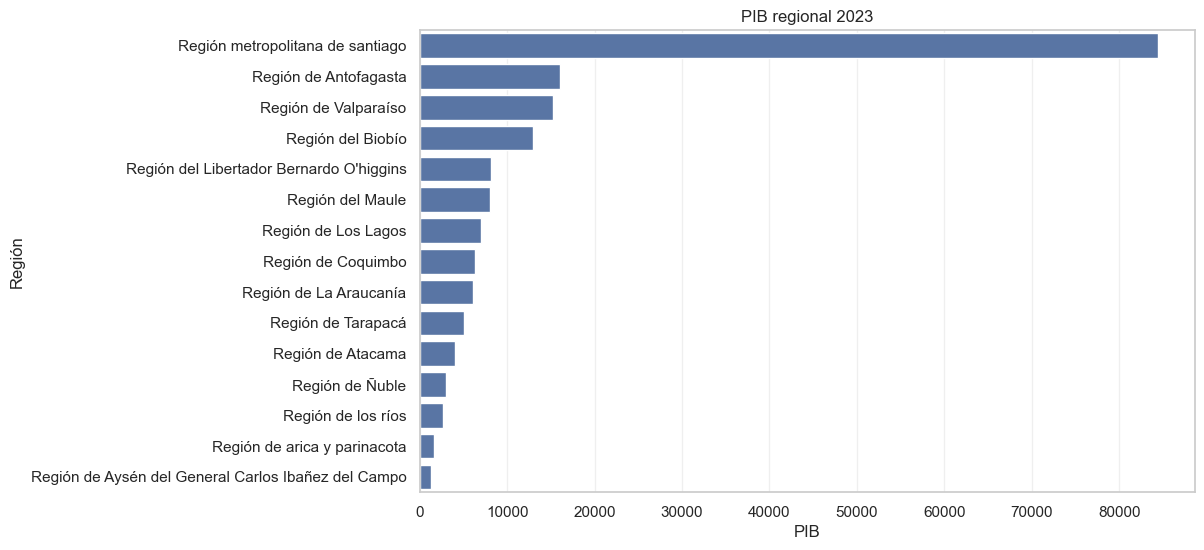

In [65]:
# ordenar regiones por PIB
tabla_pib = base_region.sort_values("pib", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=tabla_pib, x="pib", y="nom_reg")
plt.title("PIB regional 2023")
plt.xlabel("PIB")
plt.ylabel("Región")
plt.grid(axis="x", alpha=0.3)
plt.show()

El gráfico evidencia una fuerte concentración del desarrollo económico en la Región Metropolitana, la cual presenta un PIB considerablemente superior al resto del país. A continuación, un pequeño grupo de regiones como Antofagasta, Valparaíso y Biobío muestran niveles intermedios de actividad económica, mientras que la mayoría de las regiones presentan niveles significativamente menores. Esta distribución refleja una marcada desigualdad territorial en el desarrollo económico de Chile.

### 4.2 Scatter PIB vs promedio Simce,

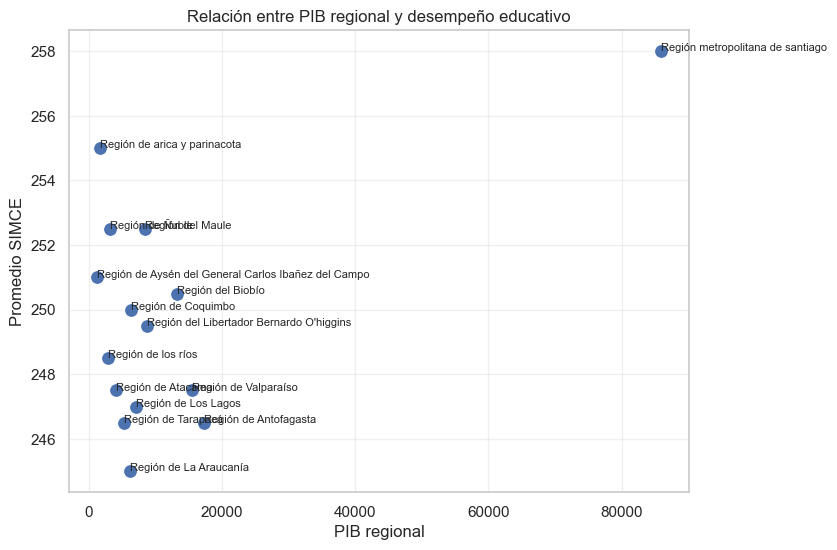

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=graf_scatter, x="pib", y="prom_simce", s=100)

for _, fila in graf_scatter.iterrows():
    plt.text(fila["pib"], fila["prom_simce"], fila["nom_reg"], fontsize=8)

plt.title("Relación entre PIB regional y desempeño educativo")
plt.xlabel("PIB regional")
plt.ylabel("Promedio SIMCE")
plt.grid(alpha=0.3)
plt.show()

El gráfico muestra una leve relación positiva entre el PIB regional y el desempeño educativo medido a través del SIMCE. En particular, la Región Metropolitana presenta tanto el mayor nivel de desarrollo económico como el mejor rendimiento académico. Sin embargo, en el resto de las regiones no se observa una relación clara, ya que regiones con niveles similares de PIB presentan resultados educativos relativamente cercanos. Esto sugiere que el desarrollo económico regional podría influir en el desempeño educativo, pero no es un factor determinante por sí solo.

### 4.4 Promedio SIMCE por región

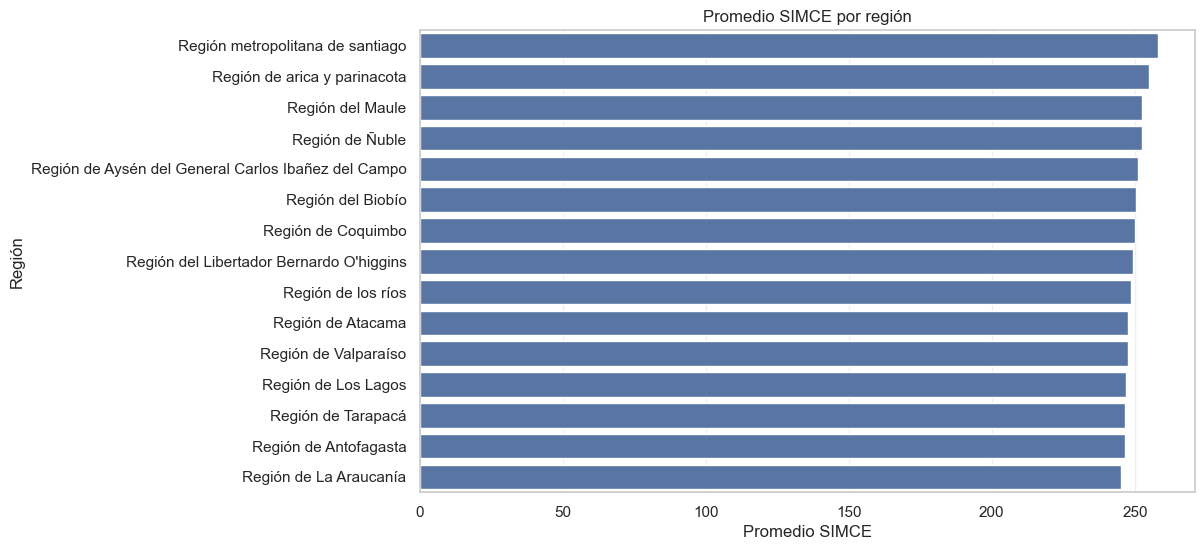

In [69]:
tabla_simce = base_region.sort_values("prom_simce", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=tabla_simce, x="prom_simce", y="nom_reg")
plt.title("Promedio SIMCE por región")
plt.xlabel("Promedio SIMCE")
plt.ylabel("Región")
plt.grid(axis="x", alpha=0.3)
plt.show()

El gráfico muestra que los puntajes SIMCE promedio por región presentan diferencias relativamente pequeñas, lo que indica un nivel de desempeño educativo bastante homogéneo a nivel territorial. Si bien la Región Metropolitana lidera el ranking, la mayoría de las regiones presenta resultados similares, lo que contrasta con la fuerte desigualdad observada en el desarrollo económico regional.

### 4.5 PIB Regional y desempeño educativo por región.

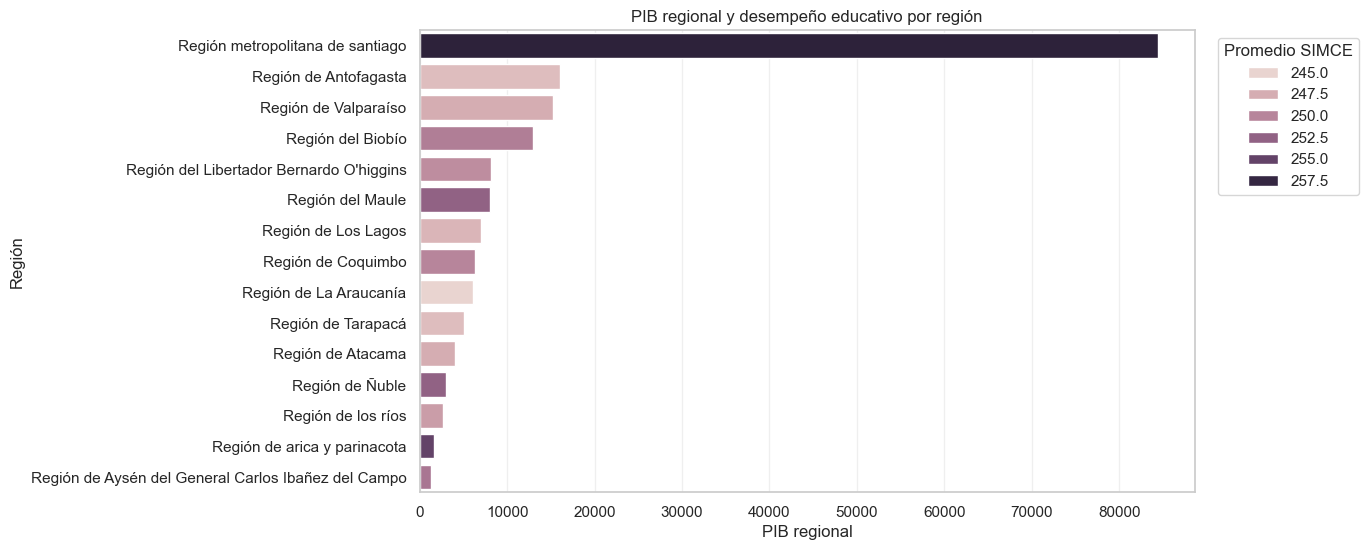

In [70]:
tabla_pib = base_region.sort_values("pib", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=tabla_pib, x="pib", y="nom_reg", hue="prom_simce", dodge=False)

plt.title("PIB regional y desempeño educativo por región")
plt.xlabel("PIB regional")
plt.ylabel("Región")
plt.legend(title="Promedio SIMCE", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="x", alpha=0.3)
plt.show()

El gráfico muestra que no existe una relación clara y consistente entre el nivel de desarrollo económico regional y el desempeño educativo. Si bien algunas regiones con mayor PIB presentan buenos resultados, existen múltiples casos en los que regiones con menor desarrollo económico alcanzan niveles similares o incluso superiores de rendimiento académico. Esto sugiere que el desarrollo económico regional no es un factor determinante por sí solo en el desempeño educativo.

### 5. Conclusión.

El análisis realizado permite observar que, si bien existe una leve relación positiva entre el desarrollo económico regional y el desempeño educativo, esta no es fuerte ni consistente entre todas las regiones. A pesar de que la Región Metropolitana presenta tanto el mayor PIB como uno de los mejores resultados en SIMCE, la mayoría de las regiones muestra niveles de rendimiento educativo bastante similares, incluso con diferencias importantes en sus niveles de desarrollo económico. Además, se identifican casos donde regiones con bajo PIB presentan buenos resultados académicos, y otras con alto PIB no destacan en desempeño. En conjunto, estos resultados sugieren que el desarrollo económico regional no es un factor determinante por sí solo en el rendimiento educativo.

### 6. Respuesta.

No necesariamente. Si bien las regiones con mayor desarrollo económico tienden a presentar un mejor desempeño educativo en algunos casos, la relación observada es débil. Existen múltiples regiones con bajo PIB que logran resultados similares o incluso superiores a regiones con mayor desarrollo económico, lo que indica que otros factores también influyen de manera importante en el desempeño educativo.

### 7. Pregunta.

¿Qué factores, además del desarrollo económico regional, influyen en el desempeño educativo de los estudiantes en Chile?